# Random Forest Model - LLM Detect AI-Generated Text

**MSE 546 - Group 13 - Part 3/4: Model Implementation**

This notebook implements a Random Forest classifier to distinguish between human-written and AI-generated essays. We use TF-IDF features along with hand-crafted stylometric features to capture writing patterns.

**Metrics:** ROC-AUC (primary), Precision, Recall, F1-Score, Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report
)
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Setup & Load Data

**If running in Google Colab**, run the cell below to upload your data file.

**If running locally** (Jupyter on your computer), skip the Colab setup cell.

We use the `train_v4_drcat_01.csv` dataset which contains ~73k essays (~37% human / ~63% AI) generated across 20+ different LLMs. This is the same dataset used in the baseline model.

In [2]:
# ============================================================
# GOOGLE COLAB SETUP - Run this cell if using Colab
# ============================================================

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally (not in Colab)")

if IN_COLAB:
    from google.colab import files
    if not os.path.exists('train_v4_drcat_01.csv'):
        print("\n" + "=" * 50)
        print("Please upload 'train_v4_drcat_01.csv'")
        print("=" * 50 + "\n")
        uploaded = files.upload()
        print("\nFile uploaded successfully!")
    else:
        print("Data file already exists, skipping upload.")

Running in Google Colab

Please upload 'train_v4_drcat_01.csv'



Saving train_v4_drcat_01.csv to train_v4_drcat_01.csv

File uploaded successfully!


In [3]:
# ============================================================
# Load Data - Automatically detects Colab vs Local
# ============================================================

possible_paths = [
    "train_v4_drcat_01.csv",                              # Colab (uploaded) or same directory
    "data/train_v4_drcat_01.csv",                          # Local (data subfolder)
    "../train_v4_drcat_01.csv",                            # Local (parent folder)
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find data file! Please either:\n"
        "1. Upload 'train_v4_drcat_01.csv' in Colab, or\n"
        "2. Place the file in the project directory locally"
    )

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

# Keep only the columns we need
X = df['text']
y = df['label']  # 0 = human, 1 = AI

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.mean():.2%} AI-generated")
print(f"Missing values in text: {X.isna().sum()}, in label: {y.isna().sum()}")

Loading data from: train_v4_drcat_01.csv

Dataset shape: (73573, 6)
Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'model']

Class distribution:
label
1    46203
0    27370
Name: count, dtype: int64

Class balance: 62.80% AI-generated
Missing values in text: 0, in label: 0


## 2. Feature Engineering

We combine two types of features:
1. **TF-IDF features** (unigrams + bigrams, 10,000 max features) — consistent with the baseline
2. **Stylometric / hand-crafted features** — capture structural writing patterns that may differ between human and AI text:
   - Text length (word count, character count, sentence count)
   - Average word length, average sentence length
   - Vocabulary richness (unique words / total words)
   - Punctuation counts (commas, periods, exclamation marks, question marks, semicolons)
   - Paragraph count
   - Average paragraph length

In [4]:
def extract_stylometric_features(texts: pd.Series) -> pd.DataFrame:
    """Extract hand-crafted stylometric features from essay texts."""
    features = pd.DataFrame(index=texts.index)

    # Basic counts
    features['char_count'] = texts.str.len()
    features['word_count'] = texts.str.split().str.len()
    features['sentence_count'] = texts.apply(lambda x: len(re.split(r'[.!?]+', str(x))) - 1)
    features['sentence_count'] = features['sentence_count'].clip(lower=1)
    features['paragraph_count'] = texts.apply(lambda x: len(str(x).split('\n\n')) if '\n\n' in str(x) else 1)

    # Averages
    features['avg_word_length'] = features['char_count'] / features['word_count'].clip(lower=1)
    features['avg_sentence_length'] = features['word_count'] / features['sentence_count']
    features['avg_paragraph_length'] = features['word_count'] / features['paragraph_count']

    # Vocabulary richness
    features['vocab_richness'] = texts.apply(
        lambda x: len(set(str(x).lower().split())) / max(len(str(x).lower().split()), 1)
    )

    # Punctuation counts
    features['comma_count'] = texts.str.count(',')
    features['period_count'] = texts.str.count(r'\.')
    features['exclamation_count'] = texts.str.count('!')
    features['question_count'] = texts.str.count(r'\?')
    features['semicolon_count'] = texts.str.count(';')

    # Punctuation ratios (per word)
    features['commas_per_word'] = features['comma_count'] / features['word_count'].clip(lower=1)
    features['periods_per_word'] = features['period_count'] / features['word_count'].clip(lower=1)

    return features

print("Extracting stylometric features...")
style_features = extract_stylometric_features(df['text'])
print(f"Stylometric features shape: {style_features.shape}")
style_features.describe().round(3)

Extracting stylometric features...
Stylometric features shape: (73573, 15)


,char_count,word_count,sentence_count,paragraph_count,avg_word_length,avg_sentence_length,avg_paragraph_length,vocab_richness,comma_count,period_count,exclamation_count,question_count,semicolon_count,commas_per_word,periods_per_word
count,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000,73573.000
mean,2302.219,385.485,19.753,5.430,5.953,20.794,87.099,0.493,18.405,19.182,0.277,0.465,0.127,0.047,0.051
std,1039.833,163.316,8.566,3.344,2.246,12.298,52.739,0.090,12.408,8.566,1.232,1.208,0.551,0.024,0.014
min,152.000,2.000,1.000,1.000,2.996,1.333,2.000,0.004,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1606.000,276.000,14.000,4.000,5.538,17.000,56.000,0.437,9.000,14.000,0.000,0.000,0.000,0.031,0.043
50%,2135.000,360.000,19.000,5.000,5.869,19.714,71.333,0.491,16.000,18.000,0.000,0.000,0.000,0.047,0.050
75%,2741.000,459.000,24.000,6.000,6.286,22.611,101.000,0.545,25.000,23.000,0.000,0.000,0.000,0.061,0.057
max,18322.000,1656.000,135.000,73.000,404.000,715.000,1656.000,1.000,295.000,216.000,31.000,73.000,27.000,0.606,1.250


## 3. Train/Test Split & TF-IDF Vectorization

We use an 80/20 stratified split (same as the baseline) and fit TF-IDF on the training set only to prevent data leakage.

In [5]:
# --- Train/Test Split ---
X_text = df['text']
y = df['label']

X_text_train, X_text_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text, y, df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_text_train)}, Test size: {len(X_text_test)}")
print(f"Train class balance: {y_train.mean():.2%} AI-generated")
print(f"Test class balance:  {y_test.mean():.2%} AI-generated")

# --- TF-IDF Vectorization (matching baseline parameters) ---
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3,
    max_df=0.9
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)
print(f"\nTF-IDF feature matrix: {X_tfidf_train.shape}")

# --- Combine TF-IDF + Stylometric Features ---
style_train = csr_matrix(style_features.loc[idx_train].values)
style_test = csr_matrix(style_features.loc[idx_test].values)

X_train = hstack([X_tfidf_train, style_train])
X_test = hstack([X_tfidf_test, style_test])
print(f"Combined feature matrix: {X_train.shape}")

Train size: 58858, Test size: 14715
Train class balance: 62.80% AI-generated
Test class balance:  62.80% AI-generated

TF-IDF feature matrix: (58858, 10000)
Combined feature matrix: (58858, 10015)


## 4. Random Forest Training


In [8]:
  best_rf = RandomForestClassifier(
      n_estimators=100,
      max_depth=50,
      min_samples_split=5,
      max_features='sqrt',
      class_weight='balanced',
      random_state=RANDOM_STATE,
      n_jobs=-1
  )

  print("Training Random Forest...")
  best_rf.fit(X_train, y_train)
  print("Training complete!")

Training Random Forest...
Training complete!


## 5. Evaluation on Test Set

In [11]:
  # --- Evaluate Model ---
  y_pred = best_rf.predict(X_test)
  y_prob = best_rf.predict_proba(X_test)[:, 1]

  roc_auc = roc_auc_score(y_test, y_prob)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  print("=" * 50)
  print("RANDOM FOREST — TEST SET RESULTS")
  print("=" * 50)
  print(f"ROC-AUC:    {roc_auc:.4f}")
  print(f"Precision:  {precision:.4f}")
  print(f"Recall:     {recall:.4f}")
  print(f"F1-Score:   {f1:.4f}")
  print()
  print("Classification Report:")
  print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI-generated (1)']))

RANDOM FOREST — TEST SET RESULTS
ROC-AUC:    0.9968
Precision:  0.9906
Recall:     0.9624
F1-Score:   0.9763

Classification Report:
                  precision    recall  f1-score   support

       Human (0)       0.94      0.98      0.96      5474
AI-generated (1)       0.99      0.96      0.98      9241

        accuracy                           0.97     14715
       macro avg       0.97      0.97      0.97     14715
    weighted avg       0.97      0.97      0.97     14715



## 6. Visualizations

### 6.1 Confusion Matrix & ROC Curve

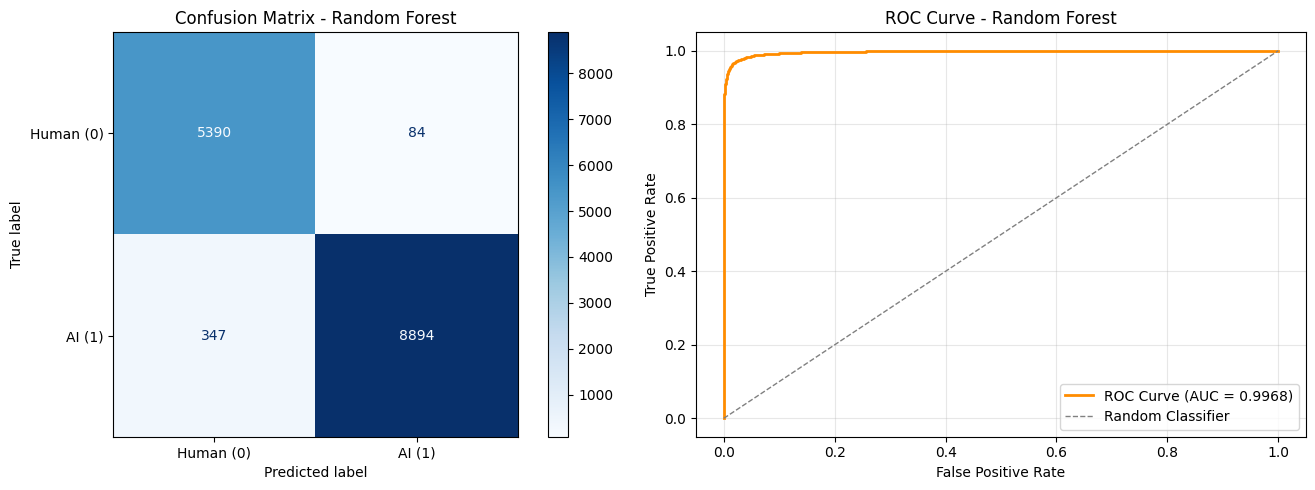

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human (0)', 'AI (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Random Forest')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('random_forest_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Feature Importance

Random Forest provides built-in feature importance via the Gini impurity decrease. We visualize the top TF-IDF features and the stylometric features separately.

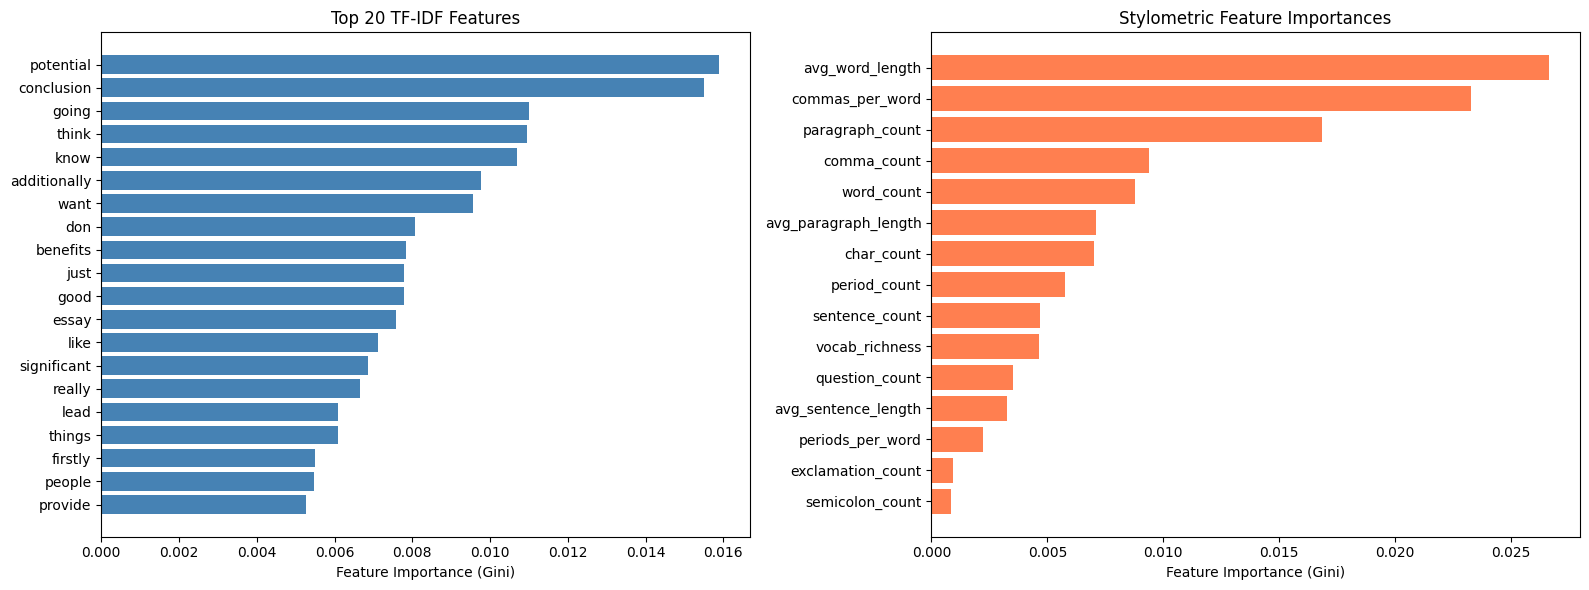

In [13]:
importances = best_rf.feature_importances_

# Split importances into TF-IDF and stylometric
n_tfidf = X_tfidf_train.shape[1]
tfidf_importances = importances[:n_tfidf]
style_importances = importances[n_tfidf:]

# --- Top 20 TF-IDF features ---
tfidf_feature_names = tfidf.get_feature_names_out()
top_tfidf_idx = np.argsort(tfidf_importances)[-20:]
top_tfidf_names = tfidf_feature_names[top_tfidf_idx]
top_tfidf_vals = tfidf_importances[top_tfidf_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(20), top_tfidf_vals, color='steelblue')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_tfidf_names)
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Top 20 TF-IDF Features')

# --- Stylometric features ---
style_names = style_features.columns.tolist()
sorted_idx = np.argsort(style_importances)
axes[1].barh(range(len(style_names)), style_importances[sorted_idx], color='coral')
axes[1].set_yticks(range(len(style_names)))
axes[1].set_yticklabels([style_names[i] for i in sorted_idx])
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Stylometric Feature Importances')

plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison with Baseline

| Model | ROC-AUC | Precision | Recall | F1-Score |
|-------|---------|-----------|--------|----------|
| **Baseline (TF-IDF + Logistic Regression)** | 0.9924 | 0.9806 | 0.9594 | 0.9699 |
| **Random Forest (TF-IDF + Stylometric)** | *see above* | *see above* | *see above* | *see above* |

In [14]:
# Print comparison summary
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<40} {'ROC-AUC':>8} {'Prec':>8} {'Recall':>8} {'F1':>8}")
print("-" * 60)
print(f"{'Baseline (TF-IDF + LogReg)':<40} {'0.9924':>8} {'0.9806':>8} {'0.9594':>8} {'0.9699':>8}")
print(f"{'Random Forest (TF-IDF + Stylometric)':<40} {roc_auc:>8.4f} {precision:>8.4f} {recall:>8.4f} {f1:>8.4f}")
print("=" * 60)

diff = roc_auc - 0.9924
if diff > 0:
    print(f"\nRandom Forest improves ROC-AUC over baseline by {diff:+.4f}")
else:
    print(f"\nRandom Forest ROC-AUC difference from baseline: {diff:+.4f}")

MODEL COMPARISON SUMMARY
Model                                     ROC-AUC     Prec   Recall       F1
------------------------------------------------------------
Baseline (TF-IDF + LogReg)                 0.9924   0.9806   0.9594   0.9699
Random Forest (TF-IDF + Stylometric)       0.9968   0.9906   0.9624   0.9763

Random Forest improves ROC-AUC over baseline by +0.0044


## 8. Key Takeaways

- **Random Forest** is an ensemble method that builds multiple decision trees and aggregates their predictions, reducing overfitting compared to a single decision tree.
- Adding **stylometric features** (sentence length, vocabulary richness, punctuation patterns) alongside TF-IDF gives the model both lexical and structural signals to distinguish human vs. AI text.
- The **feature importance** plots above reveal which words and writing style metrics are most discriminative — useful for interpretability and understanding *why* a text is classified as AI-generated.
- `class_weight='balanced'` handles the class imbalance in the dataset by assigning higher weight to the minority class during training.
- Hyperparameters were tuned via 5-fold stratified cross-validation optimizing ROC-AUC.